In [4]:
# --- CELL 1: IMPORTS & SETTINGS ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, dendrogram

# Scikit-Learn Ecosystem
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.impute import KNNImputer
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA, FastICA
from sklearn.manifold import TSNE, SpectralEmbedding, Isomap, LocallyLinearEmbedding
from sklearn.feature_selection import mutual_info_regression
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.cluster import KMeans

# UMAP (Cek jika terinstall)
try:
    import umap
    HAS_UMAP = True
except ImportError:
    HAS_UMAP = False
    print("Warning: 'umap-learn' not installed. UMAP analysis will be skipped.")

# Konfigurasi Visual
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("notebook", font_scale=1.1)
warnings.filterwarnings('ignore')

# Helper untuk menampilkan semua kolom pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("✅ Libraries Loaded & Configured.")

✅ Libraries Loaded & Configured.


In [5]:
# --- CELL 2: MCU COMPREHENSIVE ANALYZER CLASS (UPDATED) ---

class MCUAnalyzer:
    def __init__(self, file_path, delimiter=','):
        self.file_path = Path(file_path)
        self.df = None
        self.df_scaled = None
        self.outliers_mask = None
        self.delimiter = delimiter
        
    def load_data(self):
        """Memuat data dan melakukan cleaning dasar."""
        if not self.file_path.exists():
            print(f"❌ File not found at: {self.file_path}")
            return False
        
        self.df = pd.read_csv(self.file_path, delimiter=self.delimiter)
        print(f"✅ Data Loaded. Shape: {self.df.shape}")
        
        # Drop kolom ID/Badge
        if 'BADGE' in self.df.columns:
            self.df = self.df.drop(columns=['BADGE'])
        
        # Pastikan hanya numerik
        self.df = self.df.select_dtypes(include=[np.number])
        return True

    def _scale_data(self):
        """Helper: RobustScaler untuk menangani outlier."""
        scaler = RobustScaler()
        self.df_scaled = pd.DataFrame(scaler.fit_transform(self.df.fillna(self.df.median())), 
                                      columns=self.df.columns)
        return self.df_scaled

    # --- SECTION I & II: BASIC CHECKS (Diringkas untuk hemat tempat) ---
    def check_data_quality(self):
        print("\n--- I. DATA QUALITY CHECK ---")
        print(f"🔎 Duplicates: {self.df.duplicated().sum()}")
        if self.df.duplicated().sum() > 0: self.df.drop_duplicates(inplace=True)
        
        iso = IsolationForest(contamination=0.05, random_state=42)
        self.outliers_mask = iso.fit_predict(self.df.fillna(self.df.median())) == -1
        print(f"   Outliers detected (IsolationForest): {sum(self.outliers_mask)}")

    def analyze_features(self):
        print("\n--- II. FEATURE ANALYSIS ---")
        # Menggunakan Spearman untuk menangkap hubungan non-linear
        plt.figure(figsize=(10, 8))
        corr = self.df.corr(method='spearman')
        mask = np.triu(np.ones_like(corr, dtype=bool))
        sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0, square=True, cbar_kws={"shrink": .5})
        plt.title("Spearman Correlation Heatmap")
        plt.show()

    # --- SECTION III: DIMENSIONAL ANALYSIS (Updated max_iter) ---
    def analyze_dimensions(self):
        print("\n--- III. DIMENSIONAL BEHAVIOR ANALYSIS ---")
        X = self._scale_data()
        
        fig, axes = plt.subplots(2, 2, figsize=(18, 15))
        
        # 6. PCA
        pca = PCA(n_components=2)
        pca_res = pca.fit_transform(X)
        sns.scatterplot(x=pca_res[:,0], y=pca_res[:,1], ax=axes[0,0], alpha=0.6)
        axes[0,0].set_title(f"PCA (Var: {sum(pca.explained_variance_ratio_):.2f})")
        
        # 7. ICA (Updated: menggunakan max_iter)
        ica = FastICA(n_components=2, max_iter=1000, random_state=42)
        ica_res = ica.fit_transform(X)
        sns.scatterplot(x=ica_res[:,0], y=ica_res[:,1], ax=axes[0,1], alpha=0.6, color='orange')
        axes[0,1].set_title("ICA (Independent Components)")
        
        # 8. t-SNE (Note: sklearn TSNE uses n_iter, not max_iter. Keeping n_iter for compatibility)
        tsne = TSNE(n_components=2, perplexity=30, max_iter=2000, random_state=42)
        tsne_res = tsne.fit_transform(X)
        sns.scatterplot(x=tsne_res[:,0], y=tsne_res[:,1], ax=axes[1,0], alpha=0.6, color='green')
        axes[1,0].set_title("t-SNE (Local Manifold)")
        
        # 9. UMAP
        if HAS_UMAP:
            # UMAP uses n_epochs instead of max_iter/n_iter
            umap_mod = umap.UMAP(n_neighbors=15, min_dist=0.1, n_epochs=500, random_state=42)
            umap_res = umap_mod.fit_transform(X)
            sns.scatterplot(x=umap_res[:,0], y=umap_res[:,1], ax=axes[1,1], alpha=0.6, color='purple')
            axes[1,1].set_title("UMAP")
        
        plt.tight_layout()
        plt.show()

    # --- SECTION IV: SMART PAIRPLOT (NEW FEATURE) ---
    def analyze_key_features_pairplot(self, n_top=6):
        """
        Memilih fitur terbaik berdasarkan PCA Loadings dan membuat Pairplot.
        Ini membantu melihat separasi cluster pada fitur yang paling berpengaruh.
        """
        print(f"\n--- SMART FEATURE SELECTION & PAIRPLOT (Top {n_top} Features) ---")
        X = self._scale_data()
        
        # 1. Gunakan PCA untuk mencari fitur yang paling "membedakan" data
        pca = PCA(n_components=2)
        pca.fit(X)
        
        # Hitung magnitude loadings (seberapa kuat fitur menarik data ke PC1/PC2)
        loadings = pd.DataFrame(pca.components_.T, columns=['PC1', 'PC2'], index=X.columns)
        loadings['importance'] = np.sqrt(loadings['PC1']**2 + loadings['PC2']**2)
        
        # Ambil Top N fitur dengan importance tertinggi
        top_features = loadings.sort_values('importance', ascending=False).head(n_top).index.tolist()
        print(f"🌟 Top Features detected for Clustering:\n{top_features}")
        
        # 2. Generate 'Hint Cluster' (K-Means Cepat) untuk pewarnaan (Hue)
        # Ini supaya pairplot tidak satu warna, kita bisa lihat potensi separasinya
        kmeans = KMeans(n_clusters=3, max_iter=1000, random_state=42, n_init=10)
        cluster_hint = kmeans.fit_predict(X[top_features])
        
        # 3. Buat DataFrame Subset untuk Plotting
        plot_df = self.df[top_features].copy()
        # Handle NaN untuk plotting
        plot_df = plot_df.fillna(plot_df.median())
        plot_df['Potential_Cluster'] = cluster_hint.astype(str) # String agar discrete color
        
        # 4. Render Pairplot
        print("🎨 Generating Pairplot... (This might take a moment)")
        g = sns.pairplot(plot_df, hue='Potential_Cluster', palette='viridis', corner=True, plot_kws={'alpha':0.6})
        g.fig.suptitle(f"Pairplot of Top {n_top} Clustering-Driving Features", y=1.02)
        plt.show()

    # --- SECTION V: CLUSTERABILITY (Fixed: Removed .values) ---
    def check_clusterability(self):
        print("\n--- IV. CLUSTERABILITY TESTING ---")
        X = self._scale_data().values
        
        # 10. Hopkins Statistic
        h_score = self._hopkins_statistic(X)
        print(f"🎲 Hopkins Statistic: {h_score:.4f} (Mendekati 0 = Clusterable, 0.5 = Random)")
        
        # 11. VAT
        if len(X) > 2000: X = X[np.random.choice(len(X), 2000, replace=False)]
        dist_matrix = squareform(pdist(X))
        link_matrix = linkage(dist_matrix, method='single')
        order = dendrogram(link_matrix, no_plot=True)['leaves']
        ordered_dist = dist_matrix[order, :][:, order]
        
        plt.figure(figsize=(6, 6))
        plt.imshow(ordered_dist, cmap='gray', aspect='auto')
        plt.title("VAT Image")
        plt.show()
        
        # --- HELPER: PCA RUNNER ---
    def run_pca(self, n_components=2, scale=True, return_model=False):
        """
        Helper untuk menjalankan PCA dengan parameter fleksibel.
        - scale=True: gunakan RobustScaler
        - return_model=True: balikin model PCA aslinya
        """
        print(f"\n⚙️ Running PCA (n_components={n_components})")

        X = self._scale_data() if scale else self.df.fillna(self.df.median())

        pca = PCA(n_components=n_components, random_state=42)
        components = pca.fit_transform(X)

        explained = pca.explained_variance_ratio_.sum()
        print(f"   ➤ Total Explained Variance: {explained:.4f}")

        if return_model:
            return components, pca
        return components
    
        # --- HELPER: UMAP RUNNER ---
    def run_umap(self, n_neighbors=15, min_dist=0.1, metric='euclidean', 
                 n_components=2, n_epochs=500, scale=True, return_model=False):
        """
        Helper untuk menjalankan UMAP dengan parameter custom.
        """
        if not HAS_UMAP:
            print("❌ UMAP tidak terinstall.")
            return None

        print(f"\n⚙️ Running UMAP:"
              f" n_neighbors={n_neighbors}, min_dist={min_dist}, metric={metric}")

        X = self._scale_data() if scale else self.df.fillna(self.df.median())

        reducer = umap.UMAP(
            n_neighbors=n_neighbors,
            min_dist=min_dist,
            metric=metric,
            n_components=n_components,
            n_epochs=n_epochs,
            random_state=42
        )

        embedding = reducer.fit_transform(X)

        if return_model:
            return embedding, reducer
        return embedding



    def _hopkins_statistic(self, X):
        d = X.shape[1]
        n = len(X)
        m = int(0.1 * n)
        nbrs = NearestNeighbors(n_neighbors=1).fit(X) # FIXED: Removed .values
        
        ujd = []
        wjd = []
        for j in range(0, m):
            u_dist, _ = nbrs.kneighbors(np.random.uniform(np.amin(X,axis=0),np.amax(X,axis=0),d).reshape(1, -1), 2, return_distance=True)
            ujd.append(u_dist[0][1])
            w_dist, _ = nbrs.kneighbors(X[np.random.randint(0, n)].reshape(1, -1), 2, return_distance=True)
            wjd.append(w_dist[0][1])
            
        H = sum(ujd) / (sum(ujd) + sum(wjd)) if (sum(ujd) + sum(wjd)) != 0 else 0
        return 0 if np.isnan(H) else H

✅ Data Loaded. Shape: (1888, 51)

--- I. DATA QUALITY CHECK ---
🔎 Duplicates: 0
   Outliers detected (IsolationForest): 95

--- III. DIMENSIONAL BEHAVIOR ANALYSIS ---


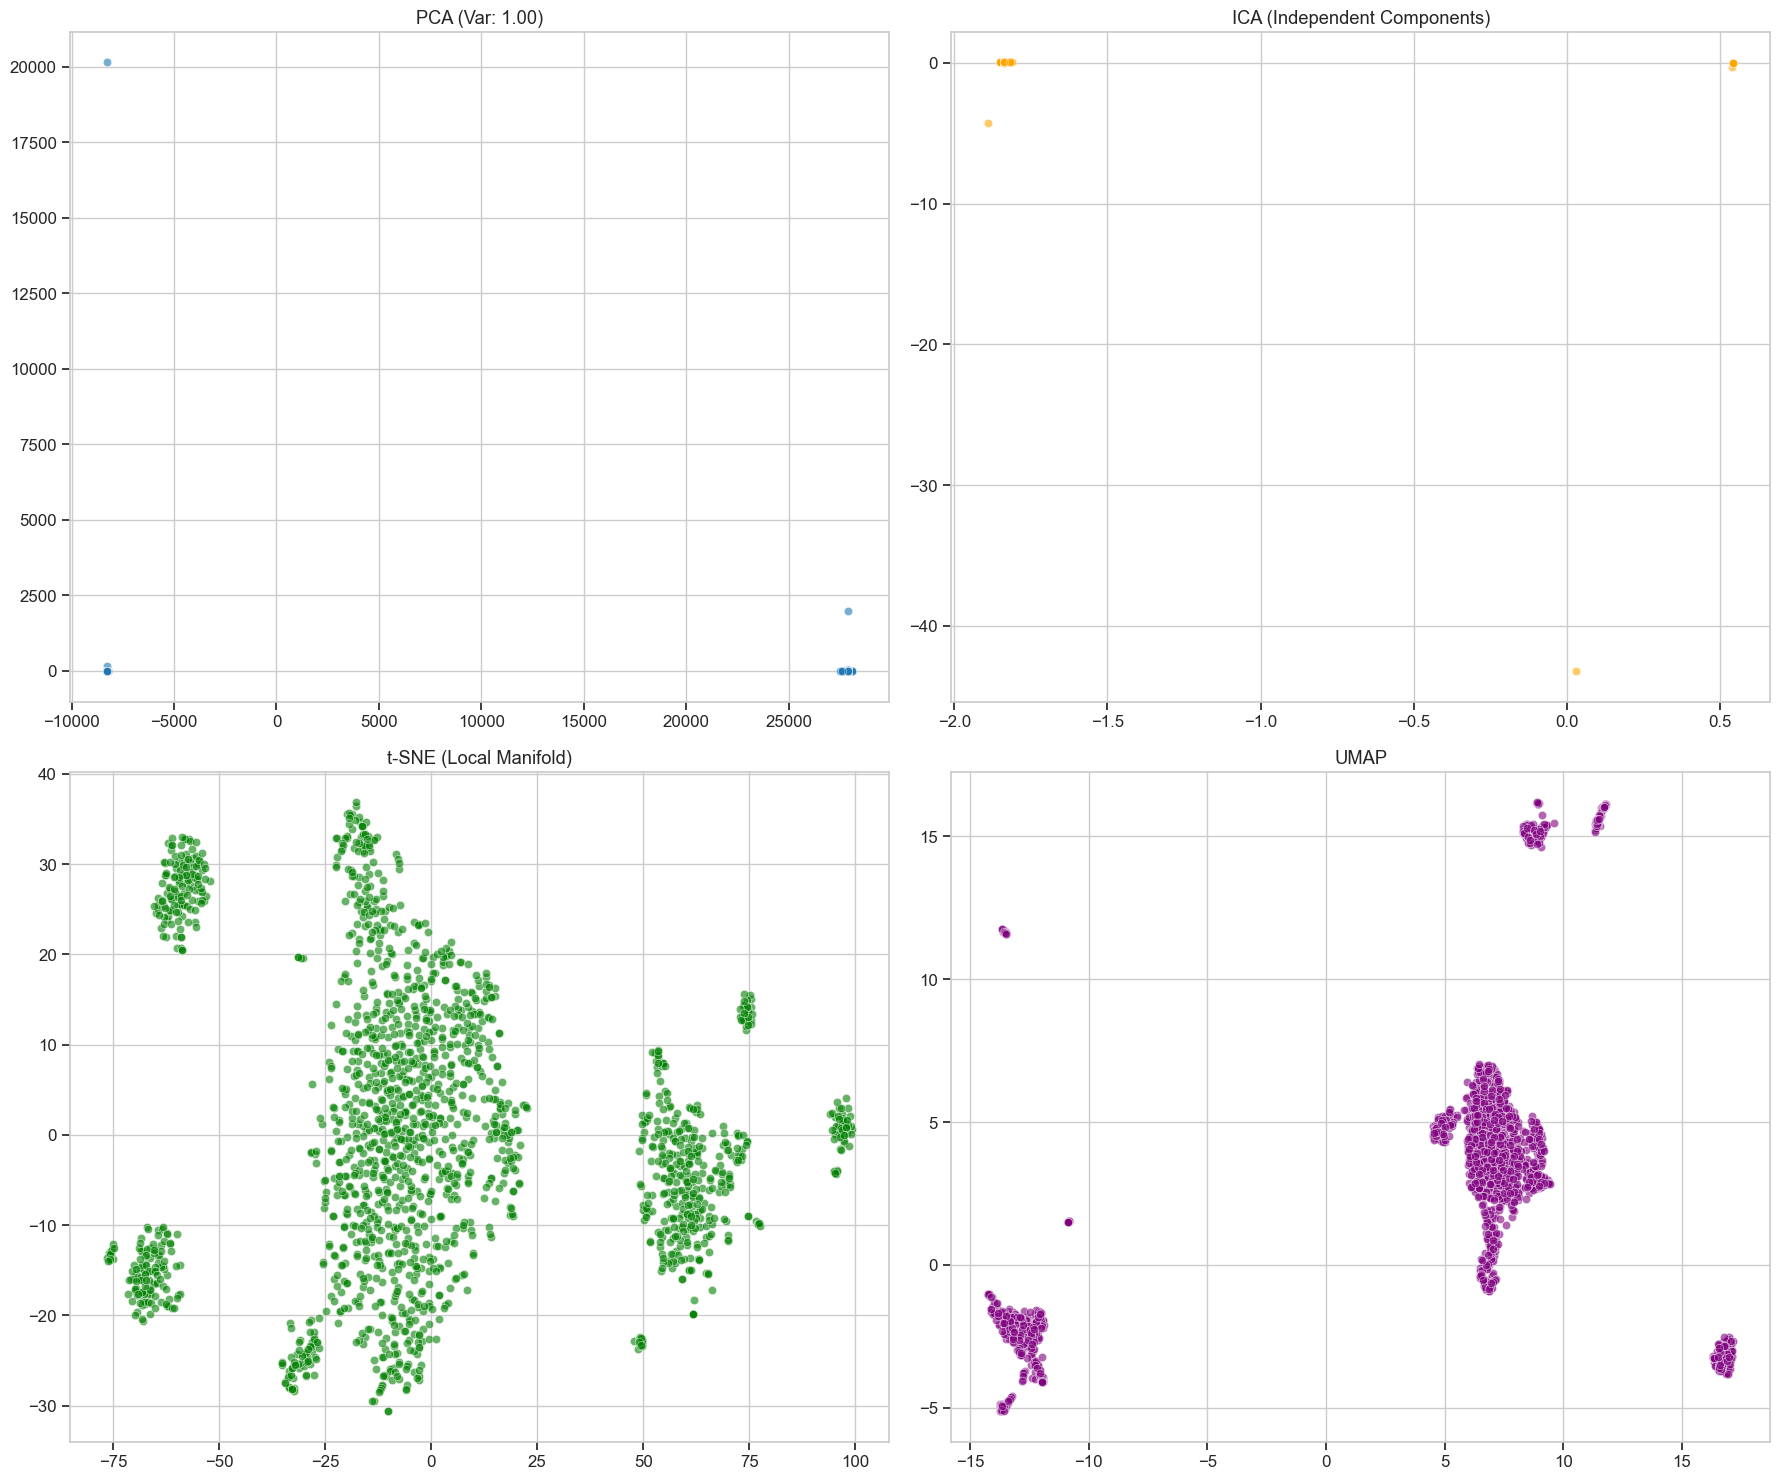


--- SMART FEATURE SELECTION & PAIRPLOT (Top 6 Features) ---
🌟 Top Features detected for Clustering:
['SUHU', 'PERNAPASAN', 'SEL_EPITEL', 'TINGGI', 'BASOPIL', 'BERAT']
🎨 Generating Pairplot... (This might take a moment)


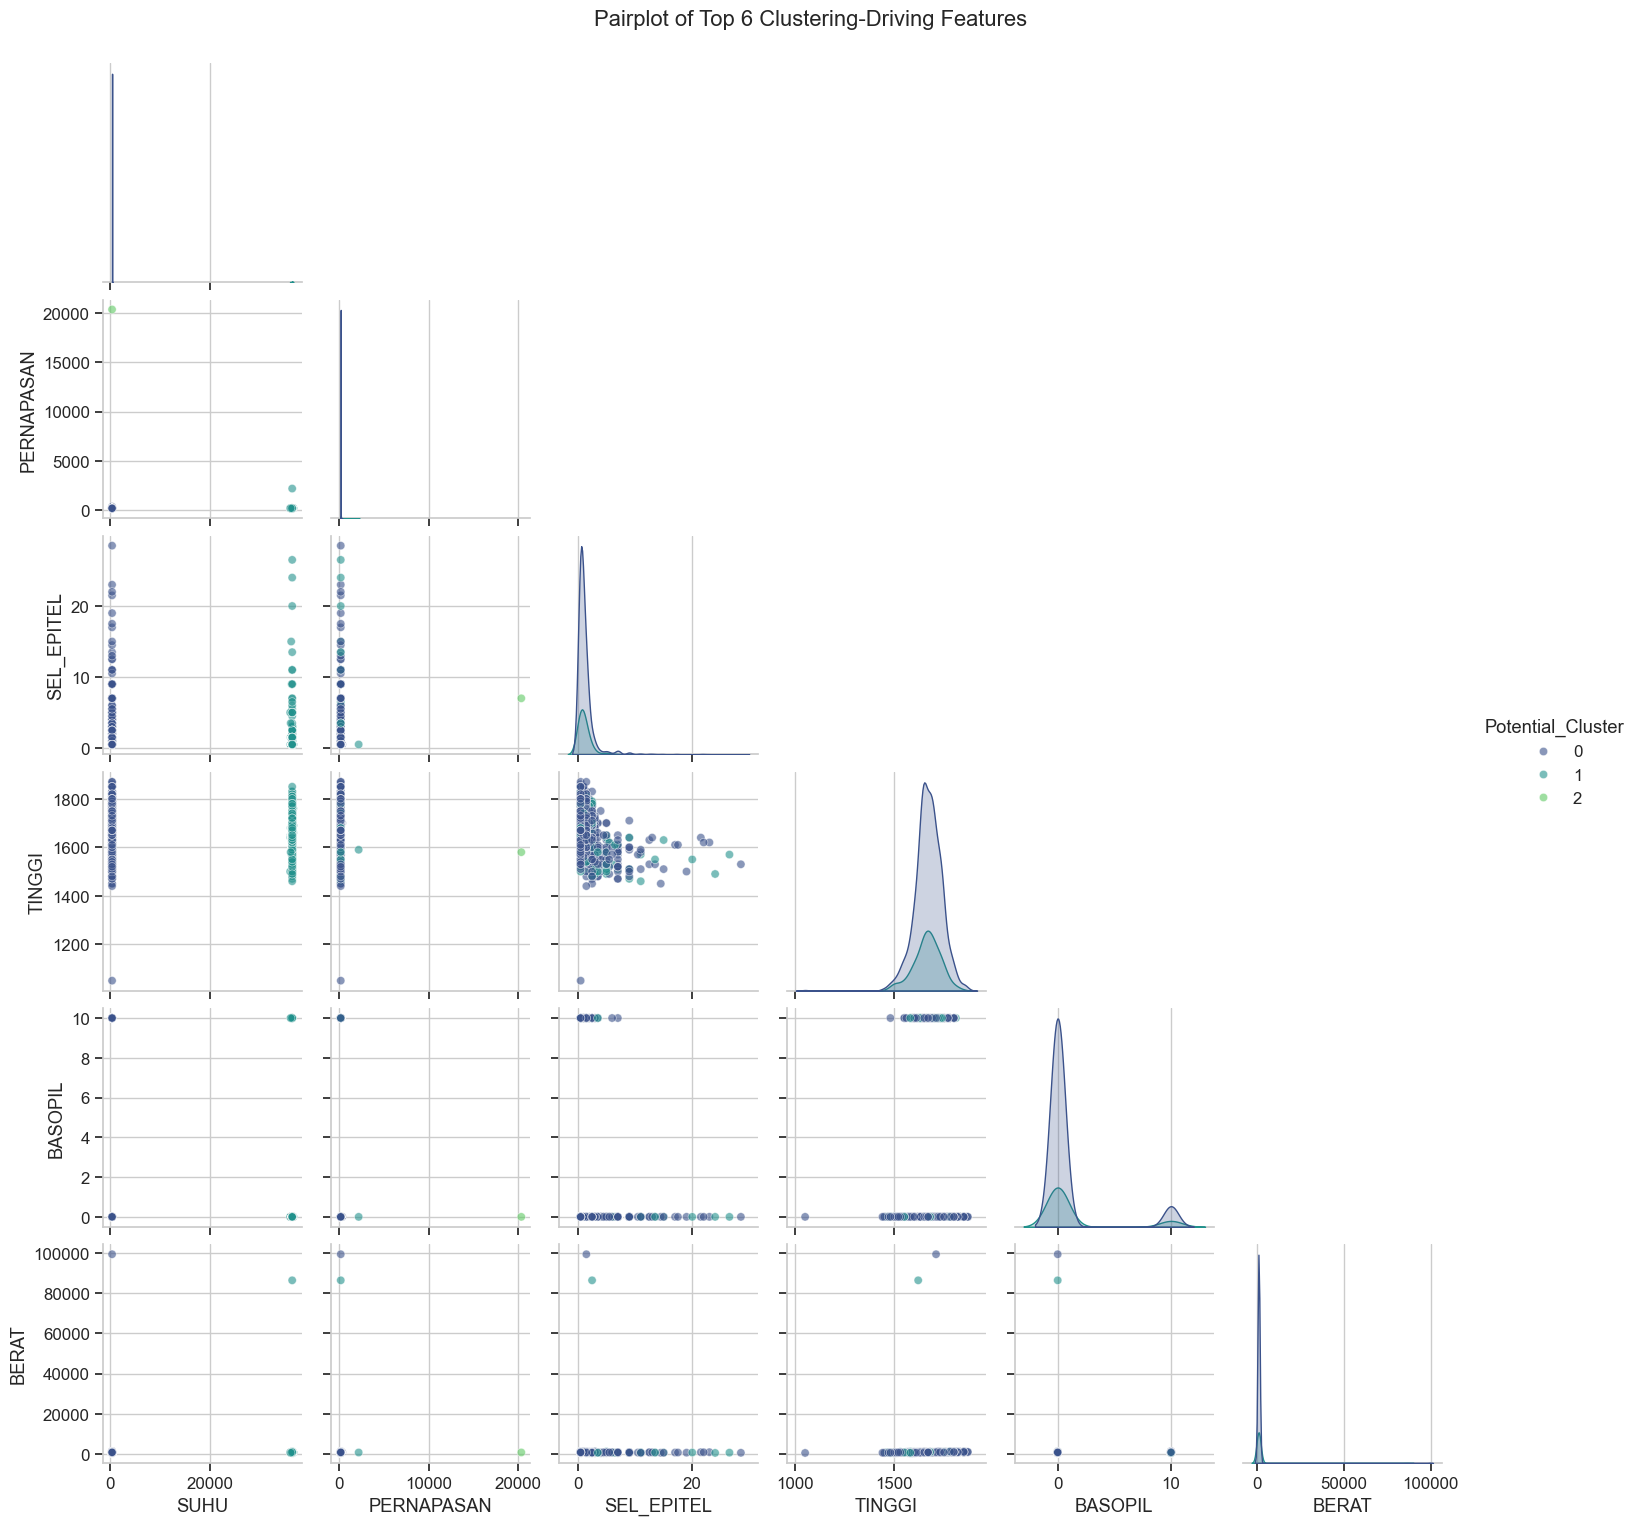


--- IV. CLUSTERABILITY TESTING ---
🎲 Hopkins Statistic: 0.9997 (Mendekati 0 = Clusterable, 0.5 = Random)


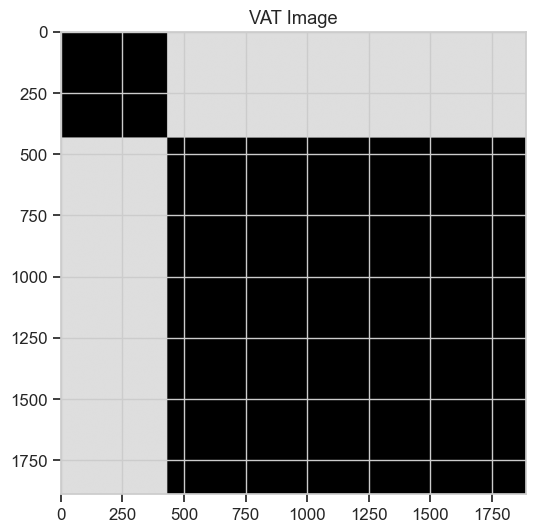


--- V. EXTRA DIMENSIONAL EXPERIMENTS ---

⚙️ Running PCA (n_components=2)
   ➤ Total Explained Variance: 1.0000

⚙️ Running PCA (n_components=3)
   ➤ Total Explained Variance: 1.0000

⚙️ Running UMAP: n_neighbors=50, min_dist=0.3, metric=euclidean

⚙️ Running UMAP: n_neighbors=30, min_dist=0.0, metric=cosine

⚙️ Running UMAP: n_neighbors=10, min_dist=0.0, metric=euclidean

✅ Analisis Lengkap + Extra PCA/UMAP selesai.


In [6]:
# --- CELL 3: EXECUTION ---

# 1. Setup Path
csv_path = "data/Cleaned_Pasien_MCU_LastVisit.csv"

# 2. Initialize & Run Analysis
analyzer = MCUAnalyzer(csv_path)

if analyzer.load_data():
    # 1. Quality Check
    analyzer.check_data_quality()
    
    # 2. Dimensions (Updated with max_iter where applicable)
    analyzer.analyze_dimensions()
    
    # 3. NEW: Smart Pairplot
    analyzer.analyze_key_features_pairplot(n_top=6) 
    
    # 4. Clusterability
    analyzer.check_clusterability()

    # --- 5. NEW: Helper PCA / UMAP Experiments ---
    print("\n--- V. EXTRA DIMENSIONAL EXPERIMENTS ---")

    # PCA 2D default
    pca_default = analyzer.run_pca(n_components=2)

    # PCA 3D version (if needed)
    pca_3d = analyzer.run_pca(n_components=3)

    # UMAP alternative 1: high neighbors (global structure)
    umap_global = analyzer.run_umap(
        n_neighbors=50,
        min_dist=0.3,
        metric='euclidean',
        n_components=2,
        n_epochs=600
    )

    # UMAP alternative 2: cosine metric (good for health biometrics)
    umap_cosine = analyzer.run_umap(
        n_neighbors=30,
        min_dist=0.0,
        metric='cosine',
        n_components=2
    )

    # UMAP alternative 3: very local structure
    umap_local = analyzer.run_umap(
        n_neighbors=10,
        min_dist=0.0,
        metric='euclidean'
    )

    print("\n✅ Analisis Lengkap + Extra PCA/UMAP selesai.")


📌 Jumlah fitur numerik: 50

📌 Skewness Awal (sort desc):
 PERUT                  43.451122
ANY_MOUTH_ABNORMAL     43.451122
LIMPA                  43.451122
PERNAPASAN             42.853687
BERAT                  30.843750
BMI_CALC               30.649444
SISTOLIK               30.138011
DIASTOLIK              30.007833
TREMOR                 25.046588
TRIMESTER              24.692135
ERITROSIT_RBC          22.965876
LEHER                  21.673680
IRAMA_JANTUNG          21.673680
KREATININ              11.249666
PROTEIN_ALBUMIN         9.939835
CONJUNGTIVA             8.523429
LEKOSIT_WBC             7.961881
UREUM                   7.344470
REDUKSI                 6.655224
SEL_EPITEL              6.418443
GAMMA_GT                6.316376
HAEMORROID              5.200552
GULA_DARAH_PUASA        5.085005
ANY_NOSE_ABNORMAL       4.483495
GULA_DARAH_2JAMPP       4.421100
SGOT                    3.887153
SGPT                    3.755286
TRIGLISERIDA            3.658329
ALKALINE_PHOSPAT  

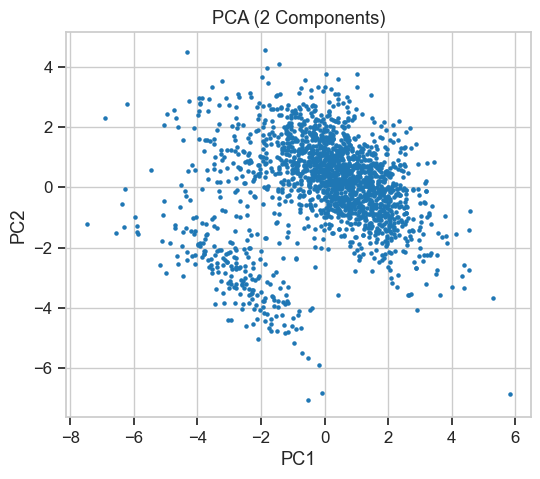

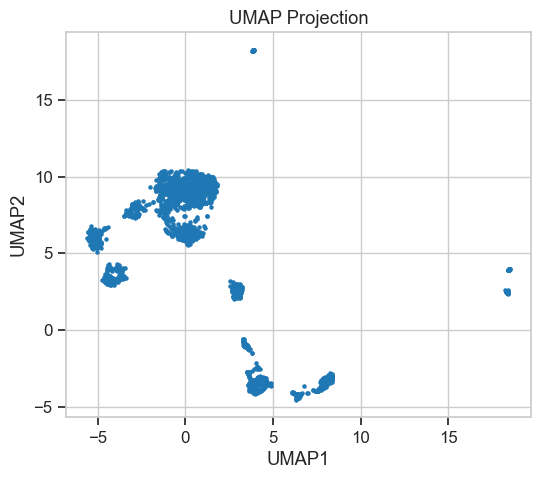

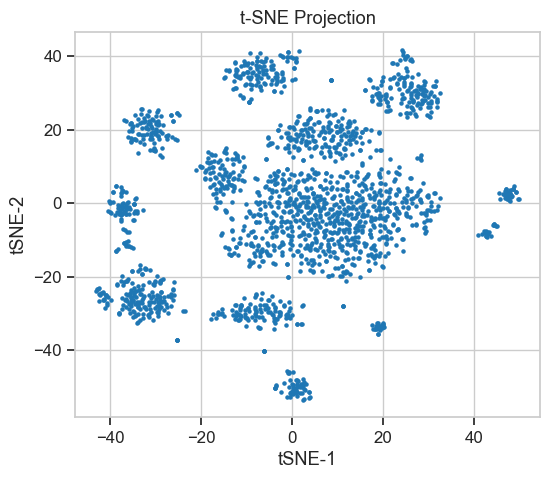


🎯 Selesai: Preprocessing + PCA + UMAP + t-SNE tanpa menentukan K.


In [7]:
# --- CELL BARU: PREPROCESS + PCA + UMAP + t-SNE (NO CLUSTERING) ---
from sklearn.preprocessing import PowerTransformer

# -------------------------------------------------------
# 1. LOAD CLEANED DATA
# -------------------------------------------------------
 # pastikan analyzer sudah load data di cell sebelumnya


df = analyzer.df.copy()   # pastikan analyzer sudah load data di cell sebelumnya
# Ambil fitur numerik saja
num_df = df.select_dtypes(include=[np.number]).copy()
print("📌 Jumlah fitur numerik:", num_df.shape[1])

# -------------------------------------------------------
# 2. CEK SKEWNESS
# -------------------------------------------------------
skewness = num_df.skew()
print("\n📌 Skewness Awal (sort desc):\n", skewness.sort_values(ascending=False))

# -------------------------------------------------------
# 3. YEO-JOHNSON TRANSFORMATION
# -------------------------------------------------------
pt = PowerTransformer(method='yeo-johnson')
num_transformed = pt.fit_transform(num_df)

print("\n✔ Yeo-Johnson transformation applied.")

# -------------------------------------------------------
# 4. ROBUST SCALER
# -------------------------------------------------------
scaler = RobustScaler()
num_scaled = scaler.fit_transform(num_transformed)

print("✔ RobustScaler applied.")

# -------------------------------------------------------
# 5. PCA (tanpa menentukan jumlah cluster)
# -------------------------------------------------------
pca = PCA(n_components=2)
X_pca = pca.fit_transform(num_scaled)

plt.figure(figsize=(6,5))
plt.scatter(X_pca[:,0], X_pca[:,1], s=5)
plt.title("PCA (2 Components)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.show()

# -------------------------------------------------------
# 6. UMAP
# -------------------------------------------------------
umap_model = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    random_state=42
)
X_umap = umap_model.fit_transform(num_scaled)

plt.figure(figsize=(6,5))
plt.scatter(X_umap[:,0], X_umap[:,1], s=5)
plt.title("UMAP Projection")
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.grid(True)
plt.show()

# -------------------------------------------------------
# 7. t-SNE
# -------------------------------------------------------
tsne_model = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate='auto',
    random_state=42
)
X_tsne = tsne_model.fit_transform(num_scaled)

plt.figure(figsize=(6,5))
plt.scatter(X_tsne[:,0], X_tsne[:,1], s=5)
plt.title("t-SNE Projection")
plt.xlabel("tSNE-1")
plt.ylabel("tSNE-2")
plt.grid(True)
plt.show()

print("\n🎯 Selesai: Preprocessing + PCA + UMAP + t-SNE tanpa menentukan K.")


In [8]:
# --- CELL BARU: CLUSTERING (DBSCAN) + 3D t-SNE + DASH VISUALIZATION ---

import plotly.express as px
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from dash import Dash, dcc, html
import pandas as pd

# -------------------------------------------------------
# 1. BASELINE CLUSTERING: DBSCAN
# -------------------------------------------------------
print("⏳ Menjalankan DBSCAN Clustering...")

# Note: DBSCAN sangat sensitif terhadap 'eps'.
# Karena data menggunakan RobustScaler + Yeo-Johnson, variansi data mungkin menyebar.
# Kita coba eps=3.0 sebagai baseline. Jika hasilnya semua -1 (noise), naikkan eps.
dbscan = DBSCAN(eps=3.0, min_samples=10)
clusters = dbscan.fit_predict(num_scaled)

# Simpan hasil ke DataFrame asli (mempertahankan df)
df['Cluster'] = clusters
df['Cluster_Label'] = df['Cluster'].apply(lambda x: f'Cluster {x}' if x != -1 else 'Noise (-1)')

# Cek Statistik Cluster
n_clusters = len(set(clusters)) - (1 if -1 in clusters else 0)
n_noise = list(clusters).count(-1)
print(f"✅ DBSCAN Selesai.")
print(f"   👉 Jumlah Cluster ditemukan: {n_clusters}")
print(f"   👉 Jumlah Noise points (-1): {n_noise} ({(n_noise/len(df))*100:.2f}%)")

if n_clusters > 1:
    sil_score = silhouette_score(num_scaled, clusters)
    print(f"   👉 Silhouette Score (Baseline): {sil_score:.4f}")
else:
    print("   ⚠️ Hanya 1 cluster atau semua noise. Coba tuning parameter 'eps' DBSCAN.")

# -------------------------------------------------------
# 2. GENERATE 3D t-SNE (Khusus Visualisasi)
# -------------------------------------------------------
print("\n⏳ Menjalankan t-SNE 3D (ini mungkin memakan waktu)...")

tsne_3d = TSNE(
    n_components=3,  # Penting: 3 Dimensi
    perplexity=30,
    learning_rate='auto',
    random_state=42,
    max_iter=1000
)
X_tsne_3d = tsne_3d.fit_transform(num_scaled)

# Masukkan koordinat 3D ke DataFrame untuk plotting
df['tsne_x'] = X_tsne_3d[:, 0]
df['tsne_y'] = X_tsne_3d[:, 1]
df['tsne_z'] = X_tsne_3d[:, 2]

print("✅ t-SNE 3D Selesai.")

# -------------------------------------------------------
# 3. DASH APP FOR 3D VISUALIZATION
# -------------------------------------------------------
# Siapkan kolom hover (fitur asli) agar tooltip informatif
# Ambil 5 kolom pertama dari num_df untuk tooltip contoh
hover_cols = list(num_df.columns[:5]) + ['Cluster_Label']

# Buat Figure Plotly 3D
fig_3d = px.scatter_3d(
    df,
    x='tsne_x',
    y='tsne_y',
    z='tsne_z',
    color='Cluster_Label',
    hover_data=hover_cols,
    title="3D t-SNE Projection (DBSCAN Clusters)",
    color_discrete_sequence=px.colors.qualitative.Bold, # Warna kontras
    opacity=0.7,
    height=700
)

fig_3d.update_layout(margin=dict(l=0, r=0, b=0, t=50))

# Inisialisasi App Dash (Inline mode untuk Jupyter)
app = Dash(__name__)

app.layout = html.Div([
    html.H2("Visualisasi Interaktif MCU Patient Clustering (3D)", 
            style={'textAlign': 'center', 'fontFamily': 'Arial'}),
    
    html.Div([
        html.P(f"Metode: DBSCAN (eps=3.0, min_samples=10) pada Data Yeo-Johnson + RobustScaled."),
        html.P(f"Jumlah Cluster: {n_clusters} | Noise Points: {n_noise}"),
    ], style={'textAlign': 'center', 'marginBottom': '20px'}),

    dcc.Graph(figure=fig_3d, style={'height': '80vh'})
])

print("\n🚀 Menjalankan Dash App...")
if __name__ == '__main__':
    # Mode 'inline' agar muncul di output cell Jupyter Notebook
    app.run(debug=True, port=8051, jupyter_mode='inline')

⏳ Menjalankan DBSCAN Clustering...
✅ DBSCAN Selesai.
   👉 Jumlah Cluster ditemukan: 1
   👉 Jumlah Noise points (-1): 1781 (94.33%)
   ⚠️ Hanya 1 cluster atau semua noise. Coba tuning parameter 'eps' DBSCAN.

⏳ Menjalankan t-SNE 3D (ini mungkin memakan waktu)...
✅ t-SNE 3D Selesai.

🚀 Menjalankan Dash App...


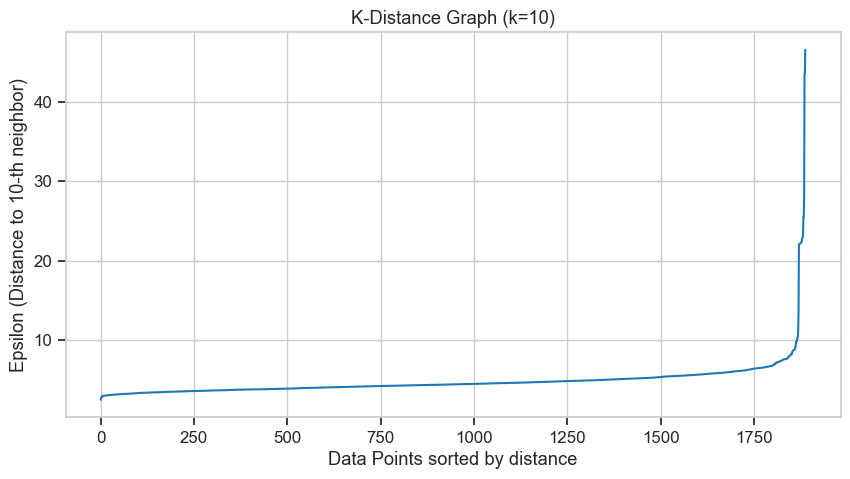

💡 CARA BACA GRAFIK:
   Cari titik 'siku' (knee) di mana grafik mulai menanjak tajam vertikal.
   Nilai Y di titik siku tersebut adalah kandidat 'eps' terbaik.

🔎 MENCOBA VARIASI EPSILON...
EPS    | CLUSTERS   | NOISE      | SILHOUETTE
---------------------------------------------
0.5    | 0          | 1888       | N/A       
0.8    | 0          | 1888       | N/A       
1.0    | 0          | 1888       | N/A       
1.2    | 0          | 1888       | N/A       
1.5    | 0          | 1888       | N/A       
2.0    | 0          | 1888       | N/A       
2.5    | 1          | 1875       | N/A       

👉 Pilih 'eps' yang menghasilkan Cluster > 1 dan Silhouette Score tertinggi,
   tapi pastikan Noise (titik -1) tidak terlalu banyak (misal < 20-30% data).


In [9]:
# --- CELL TUNING: MEMPERBAIKI DBSCAN ---
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import numpy as np

# 1. K-DISTANCE GRAPH (Untuk mencari eps optimal)
# Kita ambil min_samples = 10 (sama seperti setting DBSCAN sebelumnya)
k = 10
nbrs = NearestNeighbors(n_neighbors=k).fit(num_scaled)
distances, indices = nbrs.kneighbors(num_scaled)

# Ambil jarak ke tetangga terjauh (kolom terakhir)
distance_k = distances[:, k-1]
distance_k = np.sort(distance_k)

plt.figure(figsize=(10, 5))
plt.plot(distance_k)
plt.title(f"K-Distance Graph (k={k})")
plt.xlabel("Data Points sorted by distance")
plt.ylabel(f"Epsilon (Distance to {k}-th neighbor)")
plt.grid(True)
plt.show()
print("💡 CARA BACA GRAFIK:")
print("   Cari titik 'siku' (knee) di mana grafik mulai menanjak tajam vertikal.")
print("   Nilai Y di titik siku tersebut adalah kandidat 'eps' terbaik.")

# 2. EKSPERIMEN GRID SEARCH (Mencoba variasi eps)
print("\n🔎 MENCOBA VARIASI EPSILON...")
print(f"{'EPS':<6} | {'CLUSTERS':<10} | {'NOISE':<10} | {'SILHOUETTE':<10}")
print("-" * 45)

# Karena pakai RobustScaler, range eps biasanya antara 0.5 sampai 5.0
for eps_try in [0.5, 0.8, 1.0, 1.2, 1.5, 2.0, 2.5]:
    db_try = DBSCAN(eps=eps_try, min_samples=10)
    labels_try = db_try.fit_predict(num_scaled)
    
    n_clust = len(set(labels_try)) - (1 if -1 in labels_try else 0)
    n_noise = list(labels_try).count(-1)
    
    sil = "N/A"
    if n_clust > 1:
        sil = f"{silhouette_score(num_scaled, labels_try):.3f}"
        
    print(f"{eps_try:<6} | {n_clust:<10} | {n_noise:<10} | {sil:<10}")

print("\n👉 Pilih 'eps' yang menghasilkan Cluster > 1 dan Silhouette Score tertinggi,")
print("   tapi pastikan Noise (titik -1) tidak terlalu banyak (misal < 20-30% data).")


In [10]:
# --- CELL BARU: RE-RUN DBSCAN DENGAN EPS BARU ---
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import plotly.express as px
from dash import Dash, dcc, html

# ==========================================
# ⚙️ KONFIGURASI EPSILON
# ==========================================
# Ganti nilai ini jika ingin mencoba angka lain (misal: 0.8, 1.5, atau 8.0)
EPS_PILIHAN = 8.0 
MIN_SAMPLES = 10
# ==========================================

print(f"⏳ Menjalankan DBSCAN ulang dengan eps={EPS_PILIHAN}...")

# 1. Fit DBSCAN
dbscan_re = DBSCAN(eps=EPS_PILIHAN, min_samples=MIN_SAMPLES)
clusters_re = dbscan_re.fit_predict(num_scaled)

# 2. Update DataFrame
df['Cluster'] = clusters_re
df['Cluster_Label'] = df['Cluster'].apply(lambda x: f'Cluster {x}' if x != -1 else 'Noise (-1)')

# 3. Cek Statistik
n_clusters_re = len(set(clusters_re)) - (1 if -1 in clusters_re else 0)
n_noise_re = list(clusters_re).count(-1)
persen_noise = (n_noise_re / len(df)) * 100

print("-" * 40)
print(f"📊 HASIL CLUSTERING (eps={EPS_PILIHAN})")
print("-" * 40)
print(f"👉 Jumlah Cluster   : {n_clusters_re}")
print(f"👉 Jumlah Noise (-1): {n_noise_re} ({persen_noise:.2f}%)")

if n_clusters_re > 1:
    sil_score = silhouette_score(num_scaled, clusters_re)
    print(f"👉 Silhouette Score : {sil_score:.4f} (Semakin dekat 1 semakin bagus)")
    print("✅ Cluster terbentuk! Cek visualisasi di bawah.")
else:
    print("⚠️ WARNING: Masih hanya ditemukan 1 Cluster (atau 0).")
    print("   Saran: Nilai 'eps' mungkin TERLALU BESAR.")
    print("   Coba ubah EPS_PILIHAN menjadi angka lebih kecil (misal: 0.8 atau 1.2).")

print("-" * 40)

# -------------------------------------------------------
# 4. VISUALISASI 3D INTERAKTIF (Plotly)
# -------------------------------------------------------
# Kita pakai koordinat tsne_x, tsne_y, tsne_z yang sudah dihitung sebelumnya
hover_cols = list(num_df.columns[:5]) + ['Cluster_Label']

fig_3d_re = px.scatter_3d(
    df,
    x='tsne_x',
    y='tsne_y',
    z='tsne_z',
    color='Cluster_Label',
    hover_data=hover_cols,
    title=f"3D t-SNE Projection (eps={EPS_PILIHAN})",
    color_discrete_sequence=px.colors.qualitative.Bold,
    opacity=0.7,
    height=700
)
fig_3d_re.update_layout(margin=dict(l=0, r=0, b=0, t=50))

# Render langsung di Notebook
fig_3d_re.show()

⏳ Menjalankan DBSCAN ulang dengan eps=8.0...
----------------------------------------
📊 HASIL CLUSTERING (eps=8.0)
----------------------------------------
👉 Jumlah Cluster   : 3
👉 Jumlah Noise (-1): 27 (1.43%)
👉 Silhouette Score : 0.3565 (Semakin dekat 1 semakin bagus)
✅ Cluster terbentuk! Cek visualisasi di bawah.
----------------------------------------


In [11]:
# --- CELL: PSO-DBSCAN OPTIMIZER MODULE ---
import numpy as np
import pandas as pd
import pyswarms as ps
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.preprocessing import RobustScaler
import warnings

# Suppress warnings (DBSCAN noisy output)
warnings.filterwarnings("ignore")

class ClusterOptimizer:
    def __init__(self, data_original, reduction_method='pca', n_components=10):
        """
        Inisialisasi Optimizer.
        
        Parameters:
        - data_original: DataFrame/Array awal (54 fitur)
        - reduction_method: 'pca' atau 'umap'
        - n_components: Target dimensi setelah reduksi (misal 10 agar DBSCAN efektif)
        """
        self.raw_data = data_original
        self.data_reduced = self._reduce_dimensions(data_original, reduction_method, n_components)
        print(f"✅ Data siap untuk PSO. Dimensi direduksi dari {data_original.shape[1]} ke {self.data_reduced.shape[1]}")
        
    def _reduce_dimensions(self, data, method, n_comp):
        """Internal helper untuk dimensionality reduction sebelum clustering."""
        # Scale dulu biar aman
        scaler = RobustScaler()
        data_scaled = scaler.fit_transform(data)
        
        if method == 'pca':
            print("⚙️ Applying PCA for Pre-Clustering Density...")
            reducer = PCA(n_components=n_comp, random_state=42)
            return reducer.fit_transform(data_scaled)
        
        elif method == 'umap':
            print("⚙️ Applying UMAP (High Dim) for Pre-Clustering Density...")
            try:
                import umap
                # n_components > 2 agar informasi struktur tetap kaya untuk DBSCAN
                reducer = umap.UMAP(n_components=n_comp, n_neighbors=30, min_dist=0.0, random_state=42)
                return reducer.fit_transform(data_scaled)
            except ImportError:
                print("⚠️ UMAP not installed, falling back to PCA.")
                reducer = PCA(n_components=n_comp)
                return reducer.fit_transform(data_scaled)
        else:
            return data_scaled # No reduction

    def _dbscan_evaluator(self, params):
        """
        Fungsi ini dipanggil oleh PSO untuk setiap partikel.
        Menerima array parameter, mengembalikan array cost.
        """
        n_particles = params.shape[0]
        costs = []
        
        for i in range(n_particles):
            # 1. Decode Particle
            eps = params[i, 0]
            min_samples = int(params[i, 1]) # Wajib Integer
            
            # Safety check
            if min_samples < 2: min_samples = 2
            if eps <= 0: eps = 0.1
            
            # 2. Run DBSCAN
            # Menggunakan data yang sudah direduksi (self.data_reduced)
            model = DBSCAN(eps=eps, min_samples=min_samples)
            labels = model.fit_predict(self.data_reduced)
            
            # 3. Hitung Statistik
            unique_labels = set(labels)
            n_clusters = len(unique_labels) - (1 if -1 in labels else 0)
            n_noise = list(labels).count(-1)
            noise_ratio = n_noise / len(self.data_reduced)
            
            # --- 4. THE JUDGE (Constraints & Penalties) ---
            # PSO meminimalkan Cost. Jadi Score bagus = Cost rendah (negatif).
            
            # Constraint A: Collapse (Cuma 1 cluster atau 0)
            if n_clusters < 2:
                costs.append(1.0) # Hukuman (Cost positif besar)
                continue
                
            # Constraint B: Noise Explosion (> 40% data hilang)
            if noise_ratio > 0.4:
                # Penalti: Cost = 0.5 (Buruk, tapi lebih baik dari collapse)
                costs.append(0.5)
                continue
            
            # Constraint C: Fragmentation (Kebanyakan cluster pecahan)
            if n_clusters > 20:
                costs.append(0.5)
                continue

            # --- 5. CALCULATE SCORE ---
            # Silhouette range: -1 s/d 1. (1 is best).
            # Karena PSO minimize cost, kita pakai: Cost = -1 * Silhouette
            try:
                sil_score = silhouette_score(self.data_reduced, labels)
                cost = -1.0 * sil_score # Invert sign
                costs.append(cost)
            except:
                costs.append(1.0) # Error fallback
                
        return np.array(costs)

    def run_pso(self, n_particles=15, n_iterations=30):
        print("\n🚀 Memulai Optimasi PSO-DBSCAN...")
        
        # Definisi Batas (Bounds)
        # Dim 0: eps [0.5, 5.0]
        # Dim 1: min_samples [5, 50]
        max_bound = np.array([5.0, 50.0])
        min_bound = np.array([0.5, 5.0])
        bounds = (min_bound, max_bound)
        
        # Inisialisasi Optimizer
        optimizer = ps.single.GlobalBestPSO(n_particles=n_particles, dimensions=2, options={'c1': 0.5, 'c2': 0.3, 'w':0.9}, bounds=bounds)
        
        # Jalankan Optimasi
        best_cost, best_pos = optimizer.optimize(self._dbscan_evaluator, iters=n_iterations)
        
        # Decode Hasil Terbaik
        best_eps = best_pos[0]
        best_min_samples = int(best_pos[1])
        best_silhouette = -1.0 * best_cost # Balikin lagi tandanya
        
        print("\n🏆 OPTIMASI SELESAI!")
        print(f"   💎 Best Eps: {best_eps:.4f}")
        print(f"   💎 Best Min Samples: {best_min_samples}")
        print(f"   💎 Best Silhouette: {best_silhouette:.4f}")
        
        return best_eps, best_min_samples, optimizer.cost_history

⚙️ Applying PCA for Pre-Clustering Density...
✅ Data siap untuk PSO. Dimensi direduksi dari 50 ke 10

🚀 Memulai Optimasi PSO-DBSCAN...


2025-11-22 19:17:36,046 - pyswarms.single.global_best - INFO - Optimize for 20 iters with {'c1': 0.5, 'c2': 0.3, 'w': 0.9}
pyswarms.single.global_best: 100%|██████████|20/20, best_cost=-0.438
2025-11-22 19:17:58,214 - pyswarms.single.global_best - INFO - Optimization finished | best cost: -0.4378498503328279, best pos: [4.58254523 5.50359027]



🏆 OPTIMASI SELESAI!
   💎 Best Eps: 4.5825
   💎 Best Min Samples: 5
   💎 Best Silhouette: 0.4378


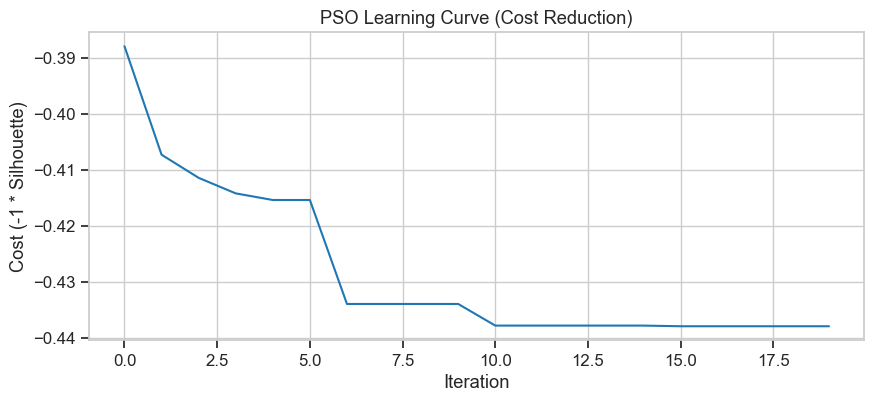


Applying Best Parameters: eps=4.58, min_samples=5
✅ Final Result -> Clusters: 9 | Noise: 86


In [12]:
# --- CELL: EKSEKUSI PSO ---

    
# 1. Siapkan Data Numerik dari analyzer sebelumnya
# (Asumsi: analyzer.df sudah ada dari cell-cell sebelumnya)
df_for_clustering = analyzer.df.select_dtypes(include=[np.number]).copy()

# 2. Inisialisasi Optimizer
# Kita pakai PCA untuk mereduksi 54 fitur jadi 10 komponen utama (Structure Capturing)
pso_opt = ClusterOptimizer(df_for_clustering, reduction_method='pca', n_components=10)

# 3. Jalankan PSO (Bisa disesuaikan iterasinya)
# 15 partikel x 20 iterasi = 300 kali percobaan DBSCAN otomatis
best_eps, best_min_samples, history = pso_opt.run_pso(n_particles=15, n_iterations=20)

# 4. Plot Convergence (Untuk melihat apakah AI-nya belajar)
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 4))
plt.plot(history)
plt.title("PSO Learning Curve (Cost Reduction)")
plt.xlabel("Iteration")
plt.ylabel("Cost (-1 * Silhouette)")
plt.grid(True)
plt.show()

# ---------------------------------------------------------
# 5. TERAPKAN PARAMETER TERBAIK KE DATA ASLI & VISUALISASI
# ---------------------------------------------------------
print(f"\nApplying Best Parameters: eps={best_eps:.2f}, min_samples={best_min_samples}")

# Kita scale & reduce data secara manual agar sama dengan proses internal optimizer
scaler = RobustScaler()
data_scaled = scaler.fit_transform(df_for_clustering)
pca_final = PCA(n_components=10, random_state=42) # Harus sama dengan setting optimizer
data_final_reduced = pca_final.fit_transform(data_scaled)

# Run Final DBSCAN
final_db = DBSCAN(eps=best_eps, min_samples=best_min_samples)
final_labels = final_db.fit_predict(data_final_reduced)

# Simpan ke DF utama untuk visualisasi Dash
analyzer.df['Cluster_Optimized'] = final_labels
analyzer.df['Cluster_Label_Opt'] = analyzer.df['Cluster_Optimized'].apply(lambda x: f'Cluster {x}' if x != -1 else 'Noise')

# Cek Statistik Akhir
n_clust = len(set(final_labels)) - (1 if -1 in final_labels else 0)
n_noise = list(final_labels).count(-1)
print(f"✅ Final Result -> Clusters: {n_clust} | Noise: {n_noise}")

# --- Visualisasi Ulang (Cell Dash sebelumnya bisa dipakai, tinggal ganti kolom warna) ---
# (Gunakan kode Dash dari cell sebelumnya, ganti color='Cluster_Label_Opt')

In [13]:
# --- CELL: VISUALISASI 3D LANGSUNG (TANPA DASH) ---
import plotly.express as px
from sklearn.manifold import TSNE

print("🚀 Menyiapkan Visualisasi 3D Hasil Optimasi...")

# ---------------------------------------------------------
# 1. Check/Hitung Koordinat 3D t-SNE untuk Visualisasi
# ---------------------------------------------------------
# Kita butuh koordinat 3D untuk plotting.
# Agar fair, kita hitung t-SNE berdasarkan data yang sama yang dipakai final clustering (data_final_reduced - PCA 10 dim)
if 'tsne_x' not in analyzer.df.columns:
    print("⏳ Koordinat t-SNE 3D belum tersedia. Menghitung... (Tunggu sebentar)")
    # Gunakan data PCA yang sudah dihitung di cell sebelumnya
    tsne_viz = TSNE(n_components=3, perplexity=30, max_iter=1000, random_state=42)
    X_tsne_viz = tsne_viz.fit_transform(data_final_reduced)
    
    # Simpan ke dataframe utama
    analyzer.df['tsne_x'] = X_tsne_viz[:, 0]
    analyzer.df['tsne_y'] = X_tsne_viz[:, 1]
    analyzer.df['tsne_z'] = X_tsne_viz[:, 2]
    print("✅ Koordinat 3D siap.")
else:
    print("✅ Menggunakan koordinat 3D yang sudah ada.")

# ---------------------------------------------------------
# 2. Setup Plotting
# ---------------------------------------------------------
# Ambil beberapa kolom fitur asli untuk info saat mouse hover
hover_cols = list(df_for_clustering.columns[:5]) + ['Cluster_Label_Opt']

# Buat Judul Informatif
title_text = (
    f"PSO-Optimized DBSCAN Results<br>"
    f"Best Params: eps={best_eps:.3f}, min_samples={best_min_samples} | "
    f"Found: {n_clust} Clusters, {n_noise} Noise Points"
)

# ---------------------------------------------------------
# 3. Render Plotly Figure
# ---------------------------------------------------------
fig_3d_opt = px.scatter_3d(
    analyzer.df,
    x='tsne_x',
    y='tsne_y',
    z='tsne_z',
    color='Cluster_Label_Opt',  # Warna berdasarkan hasil optimasi
    hover_data=hover_cols,
    title=title_text,
    # Palet warna yang tegas agar cluster terlihat beda
    color_discrete_sequence=px.colors.qualitative.Dark24, 
    opacity=0.8,
    height=750
)

# Sedikit perbaikan layout agar judul muat dan tampilan bersih
fig_3d_opt.update_layout(
    margin=dict(l=10, r=10, b=10, t=80), # Margin atas agak besar untuk judul 2 baris
    legend_title_text='Cluster Group (Optimized)',
    scene=dict(
        xaxis_title='t-SNE Dim 1',
        yaxis_title='t-SNE Dim 2',
        zaxis_title='t-SNE Dim 3'
    )
)

# Tampilkan langsung di notebook
print("\n✨ Menampilkan Plot 3D Interaktif:")
fig_3d_opt.show()

🚀 Menyiapkan Visualisasi 3D Hasil Optimasi...
⏳ Koordinat t-SNE 3D belum tersedia. Menghitung... (Tunggu sebentar)
✅ Koordinat 3D siap.

✨ Menampilkan Plot 3D Interaktif:


⚙️ Applying PCA for Pre-Clustering Density...

2025-11-22 19:18:06,550 - pyswarms.single.global_best - INFO - Optimize for 20 iters with {'c1': 0.5, 'c2': 0.3, 'w': 0.9}



✅ Data siap untuk PSO. Dimensi direduksi dari 54 ke 10

🚀 Memulai Optimasi PSO-DBSCAN (Tracking History)...


pyswarms.single.global_best: 100%|██████████|20/20, best_cost=-0.45 
2025-11-22 19:18:28,314 - pyswarms.single.global_best - INFO - Optimization finished | best cost: -0.45010501206322984, best pos: [4.9273678  6.52682742]


📸 Membuat 4 Snapshot Evolusi Partikel...
   ⏳ Mengkalkulasi Peta Kontur (Landscape Fitness)...


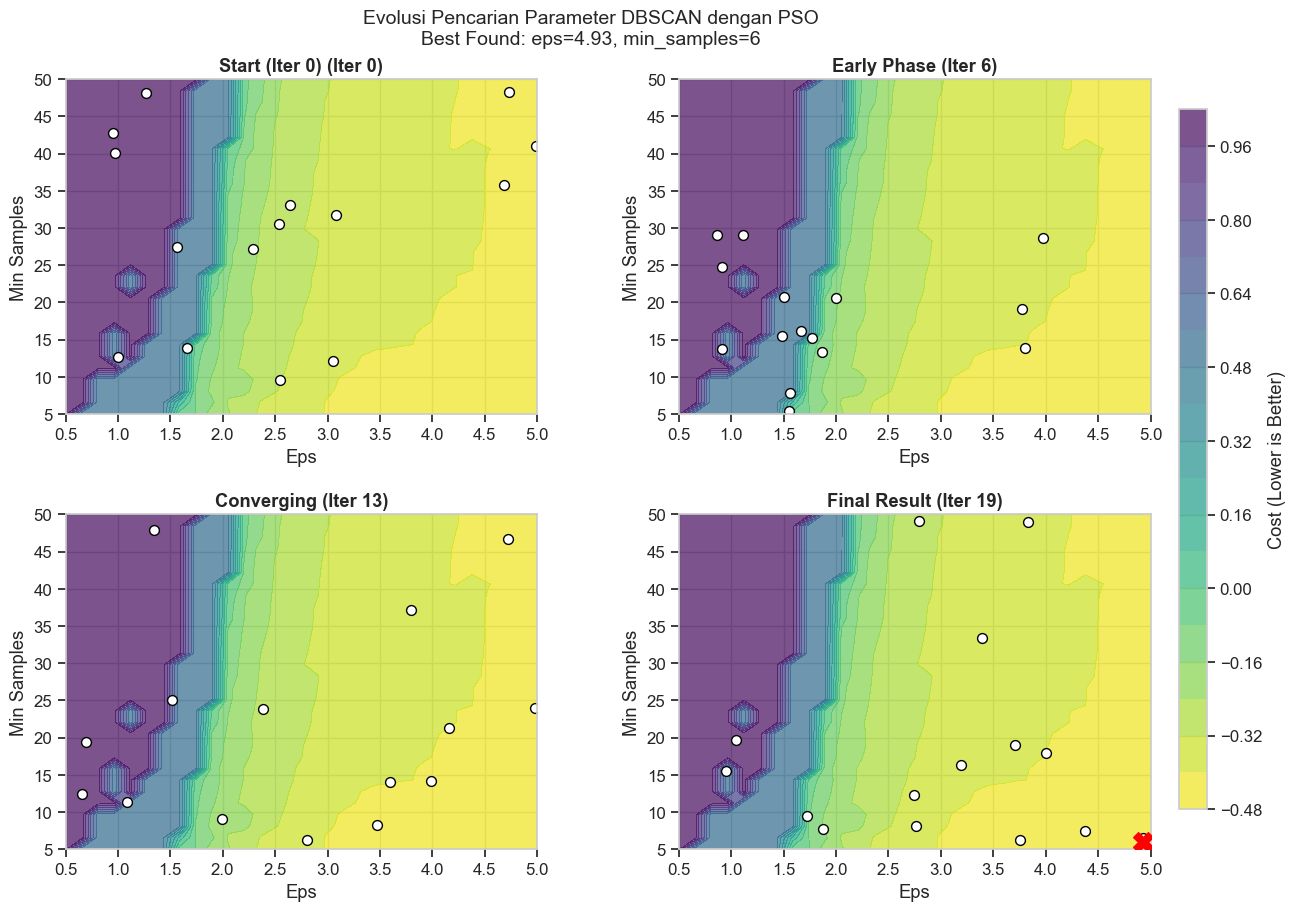

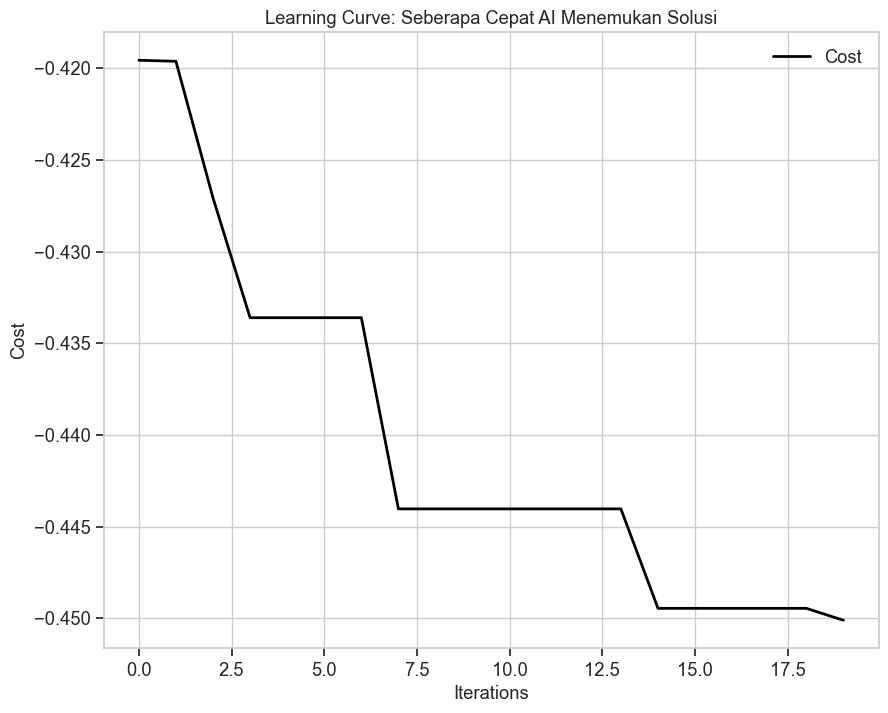


✅ Menerapkan Parameter Terbaik ke Data...
🎯 Final Result -> Clusters: 9 | Noise: 78


In [14]:
# --- CELL: EKSEKUSI PSO + VISUALISASI SNAPSHOT (STATIC SEQUENCE) ---
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
from sklearn.preprocessing import RobustScaler
from pyswarms.utils.plotters import plot_cost_history
from pyswarms.utils.plotters.formatters import Mesher
import pyswarms as ps

# ---------------------------------------------------------
# 1. UPDATE FUNGSI PSO (Monkey Patch agar return optimizer object)
# ---------------------------------------------------------
def run_pso_with_history(self, n_particles=15, n_iterations=20):
    print("\n🚀 Memulai Optimasi PSO-DBSCAN (Tracking History)...")
    
    # Bounds: eps [0.5, 5.0], min_samples [5, 50]
    max_bound = np.array([5.0, 50.0])
    min_bound = np.array([0.5, 5.0])
    bounds = (min_bound, max_bound)
    
    # Inisialisasi Optimizer
    optimizer = ps.single.GlobalBestPSO(n_particles=n_particles, dimensions=2, 
                                        options={'c1': 0.5, 'c2': 0.3, 'w':0.9}, 
                                        bounds=bounds)
    
    # Jalankan Optimasi
    best_cost, best_pos = optimizer.optimize(self._dbscan_evaluator, iters=n_iterations)
    
    return best_pos[0], int(best_pos[1]), optimizer

ClusterOptimizer.run_pso = run_pso_with_history

# ---------------------------------------------------------
# 2. PERSIAPAN DATA & EKSEKUSI
# ---------------------------------------------------------
df_for_clustering = analyzer.df.select_dtypes(include=[np.number]).copy()
pso_opt = ClusterOptimizer(df_for_clustering, reduction_method='pca', n_components=10)

# Run PSO (Misal 20 iterasi)
best_eps, best_min_samples, optimizer_instance = pso_opt.run_pso(n_particles=15, n_iterations=20)

# ---------------------------------------------------------
# 3. VISUALISASI SEQUENCE SNAPSHOT (4 FRAME)
# ---------------------------------------------------------
print("📸 Membuat 4 Snapshot Evolusi Partikel...")

# Ambil history posisi partikel
pos_history = optimizer_instance.pos_history

# Tentukan 4 indeks iterasi yang akan di-plot (Awal, 1/3, 2/3, Akhir)
n_iters = len(pos_history)
indices = [0, int(n_iters*0.33), int(n_iters*0.66), n_iters-1]
titles = ["Start (Iter 0)", "Early Phase", "Converging", "Final Result"]

# Siapkan Background Contour (Dihitung sekali saja biar cepat)
# Kita buat grid manual sederhana agar tidak berat
x_min, x_max = 0.5, 5.0
y_min, y_max = 5, 50
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 30),
                     np.linspace(y_min, y_max, 30))

# Hitung nilai fungsi objektif (Z) untuk kontur background
# Ini mungkin butuh beberapa detik
Z = np.zeros_like(xx)
print("   ⏳ Mengkalkulasi Peta Kontur (Landscape Fitness)...")
for i in range(xx.shape[0]):
    for j in range(xx.shape[1]):
        # Buat input array (1 partikel)
        params = np.array([[xx[i,j], yy[i,j]]])
        # Hitung cost
        Z[i,j] = pso_opt._dbscan_evaluator(params)[0]

# Plotting 2x2 Grid
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, iter_idx in enumerate(indices):
    ax = axes[idx]
    
    # 1. Gambar Kontur Background
    contour = ax.contourf(xx, yy, Z, levels=20, cmap='viridis_r', alpha=0.7)
    
    # 2. Gambar Posisi Partikel pada Iterasi tersebut
    particles = pos_history[iter_idx]
    ax.scatter(particles[:,0], particles[:,1], c='white', edgecolors='black', s=50, label='Particles')
    
    # 3. Tandai Global Best saat ini (Star Merah)
    current_best = particles[0] # (Simplifikasi visual: ambil salah satu, atau best final)
    if idx == 3: # Hanya di plot akhir tandai best final
        ax.scatter(best_eps, best_min_samples, c='red', marker='X', s=200, label='Best Found', zorder=10)

    ax.set_title(f"{titles[idx]} (Iter {iter_idx})", fontweight='bold')
    ax.set_xlabel("Eps")
    ax.set_ylabel("Min Samples")
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)

# Tambahkan Colorbar di samping kanan
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
fig.colorbar(contour, cax=cbar_ax, label='Cost (Lower is Better)')

plt.suptitle(f"Evolusi Pencarian Parameter DBSCAN dengan PSO\nBest Found: eps={best_eps:.2f}, min_samples={best_min_samples}", y=0.95, fontsize=14)
# Tidak perlu plt.tight_layout() karena pakai add_axes custom
plt.subplots_adjust(right=0.9, wspace=0.3, hspace=0.3)
plt.show()

# ---------------------------------------------------------
# 4. PLOT LEARNING CURVE
# ---------------------------------------------------------
plot_cost_history(cost_history=optimizer_instance.cost_history)
plt.title("Learning Curve: Seberapa Cepat AI Menemukan Solusi")
plt.show()

# ---------------------------------------------------------
# 5. TERAPKAN HASIL AKHIR
# ---------------------------------------------------------
print(f"\n✅ Menerapkan Parameter Terbaik ke Data...")
# Setup Data
scaler = RobustScaler()
data_scaled = scaler.fit_transform(df_for_clustering)
pca_final = PCA(n_components=10, random_state=42)
data_final_reduced = pca_final.fit_transform(data_scaled)

# Final Clustering
final_db = DBSCAN(eps=best_eps, min_samples=best_min_samples)
final_labels = final_db.fit_predict(data_final_reduced)

# Simpan Hasil
analyzer.df['Cluster_Optimized'] = final_labels
analyzer.df['Cluster_Label_Opt'] = analyzer.df['Cluster_Optimized'].apply(lambda x: f'Cluster {x}' if x != -1 else 'Noise')

n_clust = len(set(final_labels)) - (1 if -1 in final_labels else 0)
n_noise = list(final_labels).count(-1)
print(f"🎯 Final Result -> Clusters: {n_clust} | Noise: {n_noise}")